## BRFSS 2020-2024 Exploration
### Branson Enani

# Intro

In this project we aim to explore which behavioral and demographic factors are associated with heavy-alcohol use, a key liver-disease risk factor.

In [4]:
%%capture
# Put this in a Jupyter notebook code cell and click Run

!python setup.py

In [5]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

In [6]:
import os
import shutil
import kagglehub


#Check to make sure data already is not in data folder
path = r"C:\Users\Branson E\Desktop\Health-Project\data"

empty = True

for _ in os.scandir(path):
    empty = False
    break

if empty:
    print("No Data in folder")
    # 1. Download via kagglehub cache
    cache_path = kagglehub.dataset_download("ajenks/brfss-2020-2024-cleaned-and-weighted")

    # 2. Define your local project data directory
    local_data_dir = "../data" if "notebooks" in os.getcwd() else "./data"
    os.makedirs(local_data_dir, exist_ok=True)

    # 3. Copy files over so they live in your repository structure
    for filename in os.listdir(cache_path):
        src_file = os.path.join(cache_path, filename)
        dst_file = os.path.join(local_data_dir, filename)
        if os.path.isfile(src_file):
            shutil.copy2(src_file, dst_file)

    print(f"Dataset files ready in: {os.path.abspath(local_data_dir)}")
else:
    print("Data already in folder")


Data already in folder


In [7]:
#Organizing our dataframes into a dictionary
from pathlib import Path

folder = Path("data")
dataframes = {}

for parquet_file in sorted(folder.glob("*.parquet")):
    name = parquet_file.stem
    dataframes[name] = pd.read_parquet(parquet_file)

print(f"Loaded {len(dataframes)} parquet files")

for name, dataframe in dataframes.items():
    print(name, dataframe.shape)

Loaded 12 parquet files
brfss_2020_2024_pooled_eda (2176776, 166)
brfss_2020_2024_pooled_ml (2176776, 129)
brfss_2020_eda (401958, 293)
brfss_2020_ml (401958, 255)
brfss_2021_eda (438693, 317)
brfss_2021_ml (438693, 278)
brfss_2022_eda (445132, 342)
brfss_2022_ml (445132, 301)
brfss_2023_eda (433323, 364)
brfss_2023_ml (433323, 322)
brfss_2024_eda (457670, 316)
brfss_2024_ml (457670, 273)


## EDA

In [8]:
eda_df = dataframes["brfss_2020_2024_pooled_eda"]
eda_df.head()

,ACEDEPRS,ACEDIVRC,ACEDRINK,ACEDRUGS,ACEHURT1,ACEHVSEX,ACEPRISN,ACEPUNCH,ACESWEAR,ACETOUCH,...,_RFSMOK3,_SEX,_SMOKER3,_STATE,_STRWT,_STSTR,_TOTINDA,_URBSTAT,_WT2RAKE,_LLCPWT_POOLED
0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,3.0,3.0,...,2.0,2.0,1.0,1.0,69.640207,11011.0,1.0,1.0,69.640207,56.867134
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.0,NaN,1.0,69.640207,11011.0,1.0,1.0,69.640207,34.256666
2,2.0,1.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,...,1.0,2.0,4.0,1.0,279.748901,11012.0,1.0,1.0,279.748901,266.873773
3,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,...,1.0,2.0,4.0,1.0,69.640207,11011.0,2.0,1.0,69.640207,259.497324
4,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,...,1.0,2.0,4.0,1.0,69.640207,11011.0,1.0,1.0,69.640207,90.963025


We're analyzing binge drinking frequency (DRNK3GE5, MAXDRNKS), obesity (_BMI5CAT, _RFBMI5), and diabetes status (DIABETE4) as our core liver-disease risk factors, alongside supporting behaviors like smoking (_SMOKER3), physical activity (_TOTINDA), and self-rated health (GENHLTH), explained by demographics (_SEX, _AGEG5YR, _EDUCAG, EMPLOY1, _IMPRACE, _STATE) and healthcare access (CHECKUP1, HAS_PERSONAL_DOCTOR), with _LLCPWT_POOLED used to weight results so they reflect the true U.S. population rather than just the raw survey sample.

In [9]:
#We want to get our dataframe filtered for our columns of interest

filtered_eda_df = eda_df[[
    # Core risk factors (liver disease proxies)
    "DRNK3GE5",
    "MAXDRNKS",
    "_BMI5CAT",
    "_RFBMI5",
    "DIABETE4",

    # Related health behaviors
    "_SMOKER3",
    "_TOTINDA",
    "GENHLTH",

    # Demographics
    "_SEX",
    "_AGEG5YR",
    "_EDUCAG",
    "EMPLOY1",
    "_IMPRACE",
    "_STATE",

    # Healthcare access
    "CHECKUP1",
    "HAS_PERSONAL_DOCTOR",

    # Weighting / design
    "_LLCPWT_POOLED",
    "SURVEY_YEAR",
]]

filtered_eda_df.head()


,DRNK3GE5,MAXDRNKS,_BMI5CAT,_RFBMI5,DIABETE4,_SMOKER3,_TOTINDA,GENHLTH,_SEX,_AGEG5YR,_EDUCAG,EMPLOY1,_IMPRACE,_STATE,CHECKUP1,HAS_PERSONAL_DOCTOR,_LLCPWT_POOLED,SURVEY_YEAR
0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,2.0,2.0,8.0,4.0,4.0,1.0,1.0,4.0,0.0,56.867134,2020
1,NaN,NaN,3.0,2.0,3.0,NaN,1.0,3.0,2.0,10.0,4.0,7.0,2.0,1.0,1.0,1.0,34.256666,2020
2,NaN,NaN,NaN,NaN,3.0,4.0,1.0,3.0,2.0,10.0,3.0,7.0,2.0,1.0,1.0,1.0,266.873773,2020
3,NaN,NaN,NaN,NaN,3.0,4.0,2.0,1.0,2.0,13.0,2.0,5.0,1.0,1.0,2.0,0.0,259.497324,2020
4,NaN,NaN,2.0,1.0,3.0,4.0,1.0,2.0,2.0,13.0,4.0,7.0,1.0,1.0,1.0,1.0,90.963025,2020


In [10]:
# Here we want to build a dictionary showing what each of our focus columns means


manual_definitions = {
    "DRNK3GE5": {
        "category": "Risk factor",
        "description": "Number of times in past 30 days respondent had 5+ (men) or 4+ (women) drinks on one occasion (binge drinking frequency)",
        "valid_values": "Numeric count of occasions",
        "missing_codes": "88=None, 77=Don't know, 99=Refused",
        "clinical_relevance": "Direct proxy for alcohol-related liver disease risk",
    },
    "MAXDRNKS": {
        "category": "Risk factor",
        "description": "Maximum number of drinks consumed on any single occasion, past 30 days",
        "valid_values": "Numeric count of drinks",
        "missing_codes": "77=Don't know, 99=Refused",
        "clinical_relevance": "Captures peak alcohol exposure, complements DRNK3GE5's frequency measure",
    },
    "_BMI5CAT": {
        "category": "Risk factor",
        "description": "Computed BMI category",
        "valid_values": "1=Underweight, 2=Normal weight, 3=Overweight, 4=Obese",
        "missing_codes": "Blank/NaN if height or weight not reported",
        "clinical_relevance": "Obesity is a core driver of NAFLD/NASH (non-alcoholic fatty liver disease)",
    },
    "_RFBMI5": {
        "category": "Risk factor",
        "description": "Computed overweight-or-obese risk flag",
        "valid_values": "1=Not overweight/obese, 2=Overweight or obese",
        "missing_codes": "9=Don't know/Missing",
        "clinical_relevance": "Simplified binary version of _BMI5CAT for quick risk-group comparisons",
    },
    "DIABETE4": {
        "category": "Risk factor",
        "description": "Ever told by a doctor that respondent has diabetes",
        "valid_values": "1=Yes, 2=Yes (pregnancy-only), 3=No, 4=No (pre-diabetes/borderline)",
        "missing_codes": "7=Don't know, 9=Refused",
        "clinical_relevance": "Diabetes and insulin resistance are strongly linked to NAFLD/NASH progression",
    },
    "_SMOKER3": {
        "category": "Behavior",
        "description": "Computed 4-level smoking status",
        "valid_values": "1=Current smoker (daily), 2=Current smoker (some days), 3=Former smoker, 4=Never smoked",
        "missing_codes": "9=Don't know/Refused/Missing",
        "clinical_relevance": "Smoking compounds cardiometabolic and general disease risk alongside alcohol/obesity",
    },
    "_TOTINDA": {
        "category": "Behavior",
        "description": "Computed leisure-time physical activity indicator (past 30 days)",
        "valid_values": "1=Had activity, 2=No activity",
        "missing_codes": "9=Don't know/Refused/Missing",
        "clinical_relevance": "Physical inactivity is a modifiable risk factor for obesity and NAFLD",
    },
    "GENHLTH": {
        "category": "Behavior",
        "description": "Self-rated general health",
        "valid_values": "1=Excellent, 2=Very good, 3=Good, 4=Fair, 5=Poor",
        "missing_codes": "7=Don't know, 9=Refused",
        "clinical_relevance": "General health context/outcome variable to compare against risk clustering",
    },
    "_SEX": {
        "category": "Demographic",
        "description": "Respondent's sex (calculated)",
        "valid_values": "1=Male, 2=Female",
        "missing_codes": "None expected",
        "clinical_relevance": "Alcohol-related liver disease thresholds and BMI risk differ by sex",
    },
    "_AGEG5YR": {
        "category": "Demographic",
        "description": "Age in 5-year groups",
        "valid_values": "1=18-24 ... 13=80+ (14 categories)",
        "missing_codes": "14=Don't know/Missing",
        "clinical_relevance": "Liver disease risk and healthcare access both vary strongly by age",
    },
    "_EDUCAG": {
        "category": "Demographic",
        "description": "Education level, grouped",
        "valid_values": "1=Did not graduate HS, 2=Graduated HS, 3=Some college/technical, 4=Graduated college",
        "missing_codes": "9=Missing",
        "clinical_relevance": "Socioeconomic proxy; often correlates with health behaviors and access to care",
    },
    "EMPLOY1": {
        "category": "Demographic",
        "description": "Employment status",
        "valid_values": "1=Employed, 2=Self-employed, 3=Out of work 1+yr, 4=Out of work <1yr, 5=Homemaker, 6=Student, 7=Retired, 8=Unable to work",
        "missing_codes": "9=Refused",
        "clinical_relevance": "Economic stability affects healthcare access and health behaviors",
    },
    "_IMPRACE": {
        "category": "Demographic",
        "description": "Imputed race/ethnicity category",
        "valid_values": "1=White NH, 2=Black NH, 3=Asian NH, 4=American Indian/Alaska Native NH, 5=Hispanic, 6=Other race NH",
        "missing_codes": "None (imputed, so no missing)",
        "clinical_relevance": "Liver disease prevalence and healthcare access both show documented racial/ethnic disparities",
    },
    "_STATE": {
        "category": "Demographic",
        "description": "State FIPS code (respondent's state)",
        "valid_values": "Numeric FIPS codes, one per state/territory",
        "missing_codes": "None",
        "clinical_relevance": "Enables geographic comparison of risk clustering",
    },
    "CHECKUP1": {
        "category": "Healthcare access",
        "description": "Time since last routine checkup",
        "valid_values": "1=Within past year, 2=Within past 2 years, 3=Within past 5 years, 4=5+ years ago, 8=Never",
        "missing_codes": "7=Don't know, 9=Refused",
        "clinical_relevance": "Delayed care may mean risk factors go undetected/unmanaged longer",
    },
    "HAS_PERSONAL_DOCTOR": {
        "category": "Healthcare access",
        "description": "[derived] Cleaned boolean: does respondent have a regular personal doctor/provider",
        "valid_values": "True/False (or 1/0)",
        "missing_codes": "Depends on derivation; verify against source column if identifiable",
        "clinical_relevance": "Having a regular provider is linked to earlier detection/management of chronic risk factors",
    },
    "_LLCPWT_POOLED": {
        "category": "Design/weighting",
        "description": "Survey weight adjusted for pooled use across 2020-2024",
        "valid_values": "Continuous positive weight",
        "missing_codes": "None expected",
        "clinical_relevance": "Required to produce population-representative (not just sample) estimates",
    },
    "SURVEY_YEAR": {
        "category": "Design/weighting",
        "description": "[derived] Standardized survey year",
        "valid_values": "2020, 2021, 2022, 2023, 2024",
        "missing_codes": "None expected",
        "clinical_relevance": "Enables year-over-year trend analysis of risk clustering",
    },
}

### Checking Missing Values

Now that we have our filtered Dataframe with columns that relate to our overall question, we want to check the missingness in the data

In [17]:
filtered_eda_df.isna().sum()/len(filtered_eda_df)

DRNK3GE5               0.533234
MAXDRNKS               0.542052
_BMI5CAT               0.101337
_RFBMI5                0.101337
DIABETE4               0.002253
_SMOKER3               0.062761
_TOTINDA               0.002421
GENHLTH                0.002707
_SEX                   0.000000
_AGEG5YR               0.000000
_EDUCAG                0.005254
EMPLOY1                0.008719
_IMPRACE               0.000000
_STATE                 0.000000
CHECKUP1               0.012791
HAS_PERSONAL_DOCTOR    0.008714
_LLCPWT_POOLED         0.000000
SURVEY_YEAR            0.000000
dtype: float64

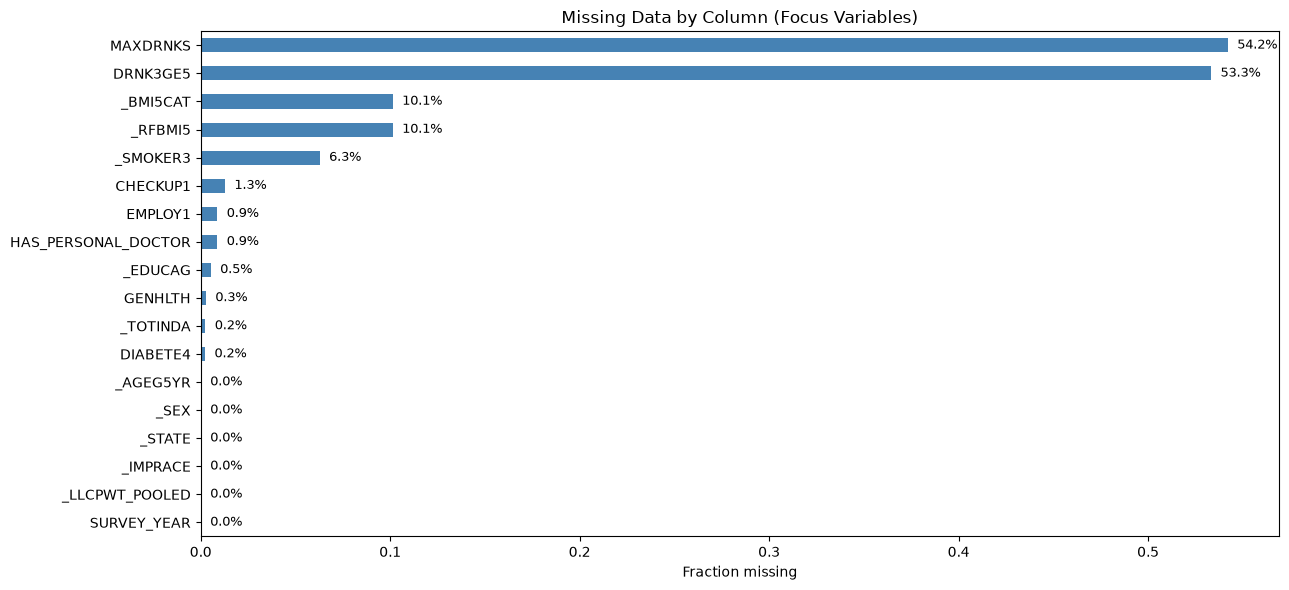

In [21]:
missing_pct = (filtered_eda_df.isna().sum() / len(filtered_eda_df)).sort_values(ascending=False)

plt.figure(figsize=(13, 6))
missing_pct.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()  # highest missingness at top
plt.xlabel("Fraction missing")
plt.title("Missing Data by Column (Focus Variables)")

# add percentage labels on each bar
for i, v in enumerate(missing_pct):
    plt.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

We can see that most data is available in the columns we have selected is available. The columns related to drinking have the most missing data with about half missing from each. However, we know that in some columns missing/unavailable data is coded as a number so let's explore these columns.

In [22]:
# Explicit missing-code map per column, pulled from your data dictionary
# (using the verified codebook values where you have them)
missing_code_map = {
    "DRNK3GE5":  [77, 99],        # 88 = "None" is a REAL answer, not missing
    "MAXDRNKS":  [77, 88, 99],    # here 88 = "Invalid response", so it IS missing
    "_BMI5CAT":  [],              # missing already shows as NaN/blank in this column
    "_RFBMI5":   [9],
    "DIABETE4":  [7, 9],
    "_SMOKER3":  [9],
    "_TOTINDA":  [9],
    "GENHLTH":   [7, 9],
    "_SEX":      [],
    "_AGEG5YR":  [14],
    "_EDUCAG":   [9],
    "EMPLOY1":   [9],
    "_IMPRACE":  [],
    "_STATE":    [],
    "CHECKUP1":  [7, 9],          # 8 = "Never" is a REAL answer, not missing
    "PERSDOC3":  [7, 9],
    "_LLCPWT_POOLED": [],
    "SURVEY_YEAR": [],
}

# Work on a copy so you don't lose the raw codes
recoded_df = filtered_eda_df.copy()

for col, missing_codes in missing_code_map.items():
    if col in recoded_df.columns and missing_codes:
        recoded_df[col] = recoded_df[col].replace(missing_codes, np.nan)

# Now compute TRUE missingness (blank + don't-know/refused codes)
true_missing_pct = (recoded_df.isna().sum() / len(recoded_df)).sort_values(ascending=False)
print(true_missing_pct)

# Compare against your original naive count to see the difference
naive_missing_pct = (filtered_eda_df.isna().sum() / len(filtered_eda_df)).sort_values(ascending=False)
comparison = pd.DataFrame({
    "naive_missing_pct": naive_missing_pct,
    "true_missing_pct": true_missing_pct,
})
comparison["difference"] = comparison["true_missing_pct"] - comparison["naive_missing_pct"]
print(comparison.sort_values("difference", ascending=False))

MAXDRNKS               0.542053
DRNK3GE5               0.533234
_BMI5CAT               0.101337
_RFBMI5                0.101337
_SMOKER3               0.062761
_AGEG5YR               0.019769
EMPLOY1                0.019593
CHECKUP1               0.012791
HAS_PERSONAL_DOCTOR    0.008714
_EDUCAG                0.005254
GENHLTH                0.002707
_TOTINDA               0.002421
DIABETE4               0.002253
_SEX                   0.000000
_STATE                 0.000000
_IMPRACE               0.000000
_LLCPWT_POOLED         0.000000
SURVEY_YEAR            0.000000
dtype: float64
                     naive_missing_pct  true_missing_pct  difference
_AGEG5YR                      0.000000          0.019769    0.019769
EMPLOY1                       0.008719          0.019593    0.010874
MAXDRNKS                      0.542052          0.542053    0.000001
CHECKUP1                      0.012791          0.012791    0.000000
DIABETE4                      0.002253          0.002253    0.00